In [1]:
# === Cell 1: Setup, load, deduplicate ===
#
# Loads the LLM-labeled dataset and removes duplicate (app, platform, version)
# rows that may have accumulated from re-runs of the data-collection notebook.

import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

INPUT = Path("data/processed/app_updates_labeled.csv")
df = pd.read_csv(INPUT, encoding="utf-8-sig")

# Parse dates and categories
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["categories_list"] = df["categories"].apply(
    lambda c: json.loads(c) if isinstance(c, str) and c.strip() else []
)

# Deduplicate on the natural key. When duplicates exist, keep the row whose
# release_notes is non-empty (richer); fall back to the first occurrence.
df["_has_notes"] = df["release_notes"].fillna("").str.strip().str.len() > 0
df = (df.sort_values(["_has_notes"], ascending=False)
        .drop_duplicates(subset=["app_name", "platform", "version"], keep="first")
        .drop(columns="_has_notes")
        .sort_values(["app_name", "platform", "release_date"], na_position="last")
        .reset_index(drop=True))

print(f"After dedup: {len(df)} rows")
print(f"  with release_notes: {(df['release_notes'].fillna('').str.strip().str.len() > 0).sum()}")
print(f"  with non-unavailable labels: {df['categories_list'].apply(lambda x: 'unavailable' not in x).sum()}")

# Set up matplotlib with a clean style
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Storage for figures we'll save in Cell 7
figures = {}

After dedup: 85 rows
  with release_notes: 41
  with non-unavailable labels: 41


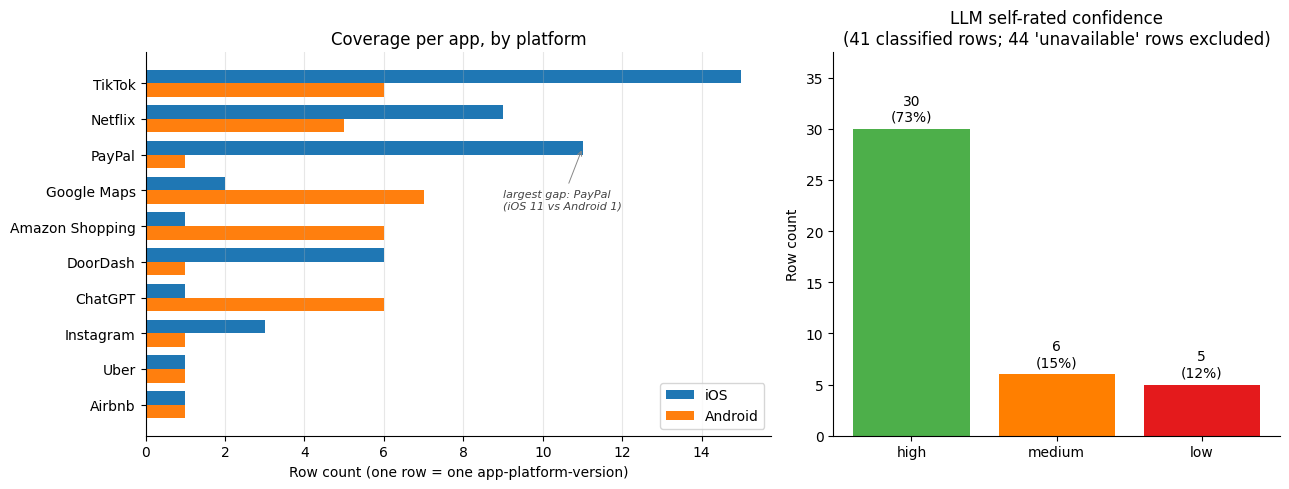

In [2]:
# === Cell 2: Dataset coverage — iOS vs Android imbalance + LLM confidence ===
#
# Two views, each addressing one specific question:
#   (a) Where did we actually get data? Highlight the iOS-Android imbalance,
#       which is structurally informative (Wayback covers iOS history;
#       APKMirror Cloudflare-blocked half of Android).
#   (b) Of the rows the LLM actually classified, how confident was it?
#       (Backfilled "unavailable" rows are excluded — including them would
#       inflate apparent confidence with rows we never sent to the LLM.)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={"width_ratios": [1.4, 1]})

# --- (a) Grouped horizontal bar: iOS vs Android row counts per app ---
counts = df.groupby(["app_name", "platform"]).size().unstack(fill_value=0)
# Order apps by total row count so the most-covered apps are visually prominent
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

y_positions = np.arange(len(counts))
bar_height = 0.38

ax1.barh(y_positions + bar_height/2, counts.get("iOS", 0),
         height=bar_height, color="#1f77b4", label="iOS")
ax1.barh(y_positions - bar_height/2, counts.get("Android", 0),
         height=bar_height, color="#ff7f0e", label="Android")
ax1.set_yticks(y_positions)
ax1.set_yticklabels(counts.index)
ax1.set_xlabel("Row count (one row = one app-platform-version)")
ax1.set_title("Coverage per app, by platform")
ax1.legend(loc="lower right")
ax1.grid(axis="x", alpha=0.3)
# Annotate the most extreme imbalance — PayPal
imbalance = (counts["iOS"] - counts["Android"]).abs()
worst = imbalance.idxmax()
worst_y = list(counts.index).index(worst)
ax1.annotate(
    f"largest gap: {worst}\n(iOS {counts.loc[worst, 'iOS']} vs Android {counts.loc[worst, 'Android']})",
    xy=(counts.loc[worst, "iOS"], worst_y + bar_height/2),
    xytext=(counts["iOS"].max() * 0.6, worst_y - 1.5),
    fontsize=8, style="italic", color="#444",
    arrowprops=dict(arrowstyle="->", color="#888", lw=0.7),
)

# --- (b) LLM confidence — only rows that were actually classified ---
classified = df[df["categories_list"].apply(lambda x: "unavailable" not in x)]
conf_counts = (classified["confidence"]
               .value_counts()
               .reindex(["high", "medium", "low"], fill_value=0))

colors = {"high": "#4daf4a", "medium": "#ff7f00", "low": "#e41a1c"}
ax2.bar(conf_counts.index, conf_counts.values,
        color=[colors[c] for c in conf_counts.index])
for level, n in conf_counts.items():
    pct = 100 * n / conf_counts.sum() if conf_counts.sum() else 0
    ax2.text(level, n + 0.5, f"{n}\n({pct:.0f}%)",
             ha="center", va="bottom", fontsize=10)
ax2.set_ylabel("Row count")
ax2.set_title(f"LLM self-rated confidence\n({len(classified)} classified rows; "
              f"{len(df) - len(classified)} 'unavailable' rows excluded)")
ax2.set_ylim(0, conf_counts.max() * 1.25)

plt.tight_layout()
figures["01_coverage_and_confidence"] = fig
plt.show()

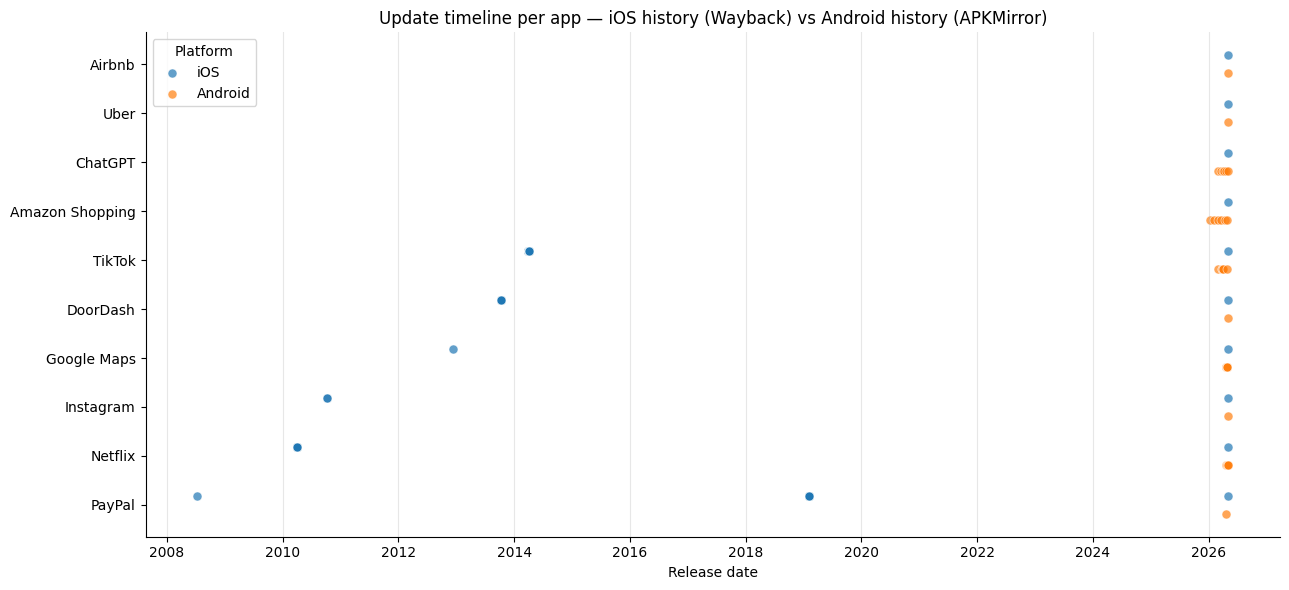

In [6]:
# === Cell 3: Update timeline — full coverage 2008-2026 ===
#
# A single full-range scatter strip per app, x-axis = release date.
# This view directly addresses the question of how update frequency
# evolves over time AND surfaces the structural finding that iOS
# and Android coverage windows barely overlap in our sample.
#
# Note: an earlier version of this cell included a 2026-only zoom
# subplot, but it was removed — half the apps had only 0-1 points
# inside the zoom window, which created visual noise rather than
# clarity.

valid = df.dropna(subset=["release_date"]).copy()
apps_ordered = (valid.groupby("app_name")["release_date"].min()
                .sort_values().index.tolist())
app_to_y = {app: i for i, app in enumerate(apps_ordered)}

fig, ax = plt.subplots(figsize=(13, 6))
platform_colors = {"iOS": "#1f77b4", "Android": "#ff7f0e"}

for platform, color in platform_colors.items():
    sub = valid[valid["platform"] == platform]
    y_jitter = 0.18 if platform == "iOS" else -0.18
    ax.scatter(sub["release_date"], sub["app_name"].map(app_to_y) + y_jitter,
               alpha=0.7, s=42, color=color, label=platform,
               edgecolors="white", linewidths=0.5)

ax.set_yticks(list(app_to_y.values()))
ax.set_yticklabels(list(app_to_y.keys()))
ax.set_xlabel("Release date")
ax.set_title("Update timeline per app — iOS history (Wayback) "
             "vs Android history (APKMirror)")
ax.legend(title="Platform", loc="upper left")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
figures["02_update_timeline"] = fig
plt.show()

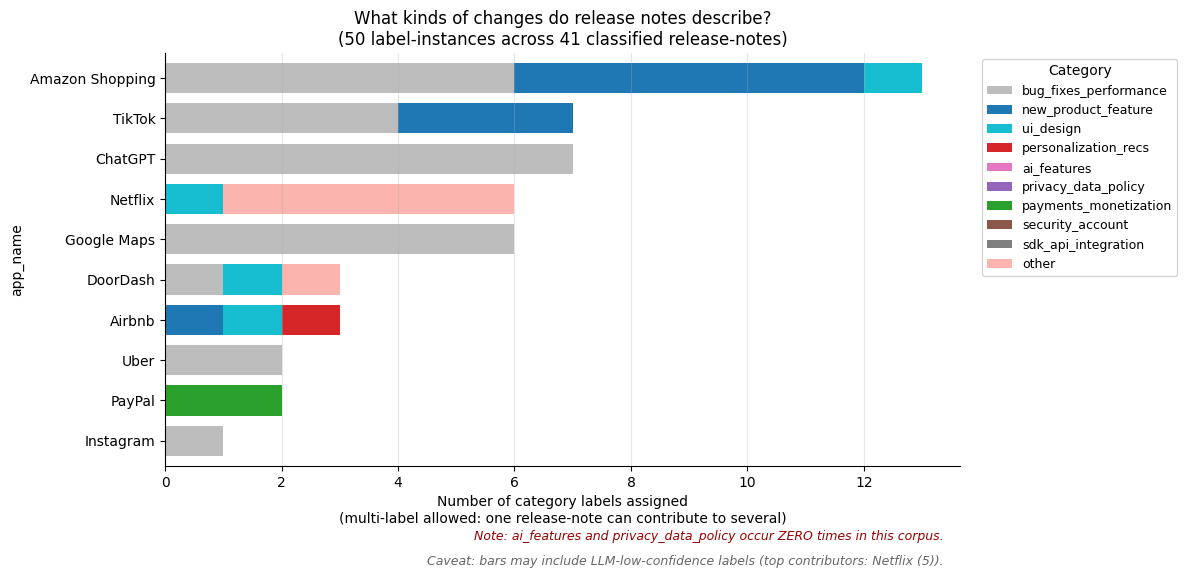


Headline finding:
  bug_fixes_performance   :  27
  new_product_feature     :  10
  ui_design               :   4
  personalization_recs    :   1
  ai_features             :   0  <-- ZERO
  privacy_data_policy     :   0  <-- ZERO
  payments_monetization   :   2
  security_account        :   0
  sdk_api_integration     :   0
  other                   :   6


In [7]:
# === Cell 4: Category composition — absolute counts (not percentages) ===
#
# Switching from per-app % to absolute count makes the sample-size truth
# visible: ChatGPT contributing 8 label-instances should look 4x larger
# than PayPal contributing 2. Percentage normalization hid that.
#
# Color reassignment: bug_fixes_performance gets neutral grey (it's the
# uninformative baseline); ai_features and privacy_data_policy get hot
# colors so their absence is conspicuous in the legend even when they
# contribute zero bar segments.

exploded = df.explode("categories_list").rename(columns={"categories_list": "cat"})
exploded = exploded[exploded["cat"].notna() & (exploded["cat"] != "unavailable")]

ct = pd.crosstab(exploded["app_name"], exploded["cat"])

# Ensure every substantive category is a column even if 0 — so legend is complete
all_cats_ordered = [
    "bug_fixes_performance",   # baseline, neutral grey
    "new_product_feature",
    "ui_design",
    "personalization_recs",    # research-relevant: warm color
    "ai_features",             # research-relevant: warm color
    "privacy_data_policy",     # research-relevant: warm color
    "payments_monetization",
    "security_account",
    "sdk_api_integration",
    "other",
]
for c in all_cats_ordered:
    if c not in ct.columns:
        ct[c] = 0
ct = ct[all_cats_ordered]

# Order apps by total label count (most-classified at top)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# Color palette — explicit, not auto-assigned
category_colors = {
    "bug_fixes_performance": "#bdbdbd",   # grey — visually suppressed baseline
    "new_product_feature":   "#1f77b4",
    "ui_design":             "#17becf",
    "personalization_recs":  "#d62728",   # red — Bian's research interest
    "ai_features":           "#e377c2",   # pink — Bian's research interest
    "privacy_data_policy":   "#9467bd",   # purple — Bian's research interest
    "payments_monetization": "#2ca02c",
    "security_account":      "#8c564b",
    "sdk_api_integration":   "#7f7f7f",
    "other":                 "#fbb4ae",
}

fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind="barh", stacked=True, ax=ax, width=0.75,
        color=[category_colors[c] for c in ct.columns])

ax.set_xlabel("Number of category labels assigned\n"
              "(multi-label allowed: one release-note can contribute to several)")
ax.set_title("What kinds of changes do release notes describe?\n"
             f"({exploded['cat'].count()} label-instances across "
             f"{exploded[['app_name','version','platform']].drop_duplicates().shape[0]} "
             f"classified release-notes)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="Category")
ax.grid(axis="x", alpha=0.3)

# Highlight the headline: ai_features and privacy_data_policy at zero
zero_cats = [c for c in ["ai_features", "privacy_data_policy"] if ct[c].sum() == 0]
if zero_cats:
    ax.text(0.98, -0.18,
            f"Note: {' and '.join(zero_cats)} occur ZERO times in this corpus.",
            transform=ax.transAxes, ha="right", fontsize=9,
            style="italic", color="#990000")
    
# Additional caveat: flag low-confidence label clusters that could mislead readers
low_conf_apps = (
    df[df["confidence"] == "low"]["app_name"].value_counts()
)
if not low_conf_apps.empty:
    flagged = ", ".join(f"{a} ({n})" for a, n in low_conf_apps.head(3).items())
    ax.text(0.98, -0.24,
            f"Caveat: bars may include LLM-low-confidence labels "
            f"(top contributors: {flagged}).",
            transform=ax.transAxes, ha="right", fontsize=9,
            style="italic", color="#666")

plt.tight_layout()
figures["03_category_per_app"] = fig
plt.show()

# Print the headline finding in text too — easy to copy into the Summary section
print("\nHeadline finding:")
for c in all_cats_ordered:
    n = ct[c].sum()
    marker = "  <-- ZERO" if n == 0 and c in ("ai_features", "privacy_data_policy") else ""
    print(f"  {c:<24}: {n:3d}{marker}")

In [9]:
# === Cell 5: Save all figures to output/figures/ ===

OUT_DIR = Path("output/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for name, fig in figures.items():
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=150, facecolor="white")
    print(f"Saved: {path}")

print(f"\nTotal: {len(figures)} figures saved")

Saved: output\figures\01_coverage_and_confidence.png
Saved: output\figures\02_update_timeline.png
Saved: output\figures\03_category_per_app.png

Total: 3 figures saved
